# Chronos-2 — Comprehensive Kernel Benchmark

Benchmarks **six** model variants across two perspectives:

**Part A — Individual Kernels vs Baseline** (4 models)

| Model | TimeSelfAttention | GroupSelfAttention |
|---|---|---|
| **Baseline** | Standard MHA (sdpa) | Standard MHA |
| **RoPE-Fused** | Triton-fused kernel | Standard MHA |
| **BSR** | Standard MHA (sdpa) | Block-Sparse-Row kernel |
| **Bucketed** | Standard MHA (sdpa) | Triton bucketed kernel |

**Part B — Combined Kernels vs Baseline** (3 models)

| Model | TimeSelfAttention | GroupSelfAttention |
|---|---|---|
| **Baseline** | Standard MHA (sdpa) | Standard MHA |
| **RoPE + BSR** | Triton-fused kernel | Block-Sparse-Row kernel |
| **RoPE + Bucketed** | Triton-fused kernel | Triton bucketed kernel |

> **Note:** `fast_bsr_group_attention_transform_pass` (BSR) is **static** — built once and reused for all batch sizes.  
> `fast_group_attention_transform_pass` (Bucketed) **requires retransform** when the batch size or group-ID distribution changes, because `KernelDispatcher` partitions groups at trace time.

**Sweeps:**
- **Batch size** ∈ [1, 2, 4, 8, 16, 32, 64, 128, 256] at fixed seq=1024
- **Sequence length** ∈ [128, 256, 512, 1024, 2048] at fixed batch=128
- All sweeps run in **univariate**, **multivariate**, and **mixed** modes

Both Part A and Part B share one combined sweep loop to avoid redundant retransforms.

## 1. Imports & Config

In [1]:
import os
import copy
import statistics
import time as _time
import warnings
import gc
import contextlib
from pathlib import Path

warnings.filterwarnings('ignore')
os.environ.setdefault('HOME', os.environ.get('USERPROFILE', str(Path.home())))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
OUTPUT_DIR = Path('artifacts/comprehensive_benchmark')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VARIATE_MODES = ['univariate', 'multivariate']

# Colours and markers — one per model variant
COLORS = {
    'baseline':      '#4C72B0',  # blue
    'rope_fused':    '#DD8452',  # orange
    'bsr':           '#2ca02c',  # green
    'bucketed':      '#9467bd',  # purple
    'rope_bsr':      '#d62728',  # red
    'rope_bucketed': '#8c564b',  # brown
}
MARKERS = {
    'baseline':      'o',
    'rope_fused':    's',
    'bsr':           '^',
    'bucketed':      'D',
    'rope_bsr':      'P',
    'rope_bucketed': 'X',
}

# Part A: individual kernel ablation — baseline + 3 single-kernel variants
PART_A_NAMES = ['baseline', 'rope_fused', 'bsr', 'bucketed']
# Part B: combined kernel — baseline + 2 dual-kernel variants
PART_B_NAMES = ['baseline', 'rope_bsr', 'rope_bucketed']

print(f'Device     : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU        : {torch.cuda.get_device_name(0)}')
print(f'Output dir : {OUTPUT_DIR}')


Device     : cuda
GPU        : NVIDIA GeForce RTX 5080
Output dir : artifacts/comprehensive_benchmark


## 2. Load Chronos-2 Model

In [2]:
from chop.models import get_model
from chop.models.chronos2.triton_rope_attn import is_triton_available as is_rope_triton_available
from chop.models.chronos2.triton_grouped_attn import is_triton_available as is_grouped_triton_available

model = get_model('chronos-2', pretrained=True)
model.eval()
model = model.to(DEVICE)

if hasattr(model.config, '_attn_implementation'):
    model.config._attn_implementation = 'sdpa'
if hasattr(model.config, 'use_cache'):
    model.config.use_cache = False

chronos_cfg = model.config.chronos_config
C_LEN       = chronos_cfg.get('context_length', 8192)
OUT_PATCH   = chronos_cfg.get('output_patch_size', 16)

print(f'Model                  : {type(model).__name__}')
print(f'Context length         : {C_LEN}')
print(f'Output patches         : {OUT_PATCH}')
print(f'Triton RoPE            : {"available ✓" if is_rope_triton_available() else "NOT available (eager fallback)"}')
print(f'Triton grouped-attn    : {"available ✓" if is_grouped_triton_available() else "NOT available (eager fallback)"}')

Model                  : Chronos2Model
Context length         : 8192
Output patches         : 16
Triton RoPE            : available ✓
Triton grouped-attn    : available ✓


## 3. Build Static Model Variants

The following variants do **not** require retransform across sweep iterations:
- **rope_fused**: `fused_rope_time_attention_transform_pass` — fuses RoPE into Triton attention kernel for every `TimeSelfAttention`
- **bsr**: `fast_bsr_group_attention_transform_pass` — replaces `GroupSelfAttention` with a Block-Sparse-Row kernel; sparsity is evaluated dynamically at forward time
- **rope_bsr**: both passes applied in sequence

The `bucketed` and `rope_bucketed` models are rebuilt on-demand during sweeps (see §5).

In [3]:
from chop import MaseGraph
from chop.passes.graph import PASSES
from chop.models.chronos2.layers import GroupSelfAttention, TimeSelfAttention
from chop.passes.graph.transforms.timeseries import (
    fused_rope_time_attention_transform_pass,
    fast_group_attention_transform_pass,
)
from chop.passes.graph.transforms.timeseries.FastBSRGroupAtten import (
    fast_bsr_group_attention_transform_pass,
)

TRACE_BATCH = 256
TRACE_SEQ   = 64

trace_in = {
    'context':            torch.randn((TRACE_BATCH, TRACE_SEQ), device=DEVICE),
    'group_ids':          torch.arange(TRACE_BATCH, dtype=torch.long, device=DEVICE),
    'num_output_patches': 1,
}

CUSTOM_OPS = {
    'modules': {
        TimeSelfAttention: {
            'args': {
                'hidden_states':     'data_in',
                'attention_mask':    'data_in',
                'position_ids':      'data_in',
                'output_attentions': 'config',
            }
        },
        GroupSelfAttention: {
            'args': {
                'hidden_states':     'data_in',
                'attention_mask':    'data_in',
                'output_attentions': 'config',
            }
        },
    },
    'functions': {}
}


def _build_mg(base_model: torch.nn.Module) -> MaseGraph:
    """Deep-copy the model, wrap in MaseGraph, and initialise metadata."""
    mg = MaseGraph(
        model=copy.deepcopy(base_model),
        hf_input_names=list(trace_in.keys()),
        custom_ops=CUSTOM_OPS,
    )
    mg, _ = PASSES['init_metadata'](mg)
    mg, _ = PASSES['add_common_metadata'](
        mg, pass_args={'dummy_in': trace_in, 'add_value': False}
    )
    return mg


def _attach_attrs(graph_module, src_model):
    """Copy config attributes needed by downstream code."""
    for attr in ('config', 'chronos_config', 'device'):
        setattr(graph_module, attr, getattr(src_model, attr))


# BSR uses GPU group_ids at transform time
bsr_group_ids_gpu = trace_in['group_ids']

# ── RoPE-Fused ──────────────────────────────────────────────────────────────
print('Building rope_fused ...')
mg_rope = _build_mg(model)
mg_rope, rope_info = fused_rope_time_attention_transform_pass(mg_rope)
_attach_attrs(mg_rope.model, model)
mg_rope.model.eval()
print(f'  TimeSelfAttention blocks replaced: {rope_info["replaced"]}')

# ── BSR ─────────────────────────────────────────────────────────────────────
print('Building bsr ...')
mg_bsr = _build_mg(model)
mg_bsr, _ = fast_bsr_group_attention_transform_pass(
    mg_bsr, pass_args={'group_ids': bsr_group_ids_gpu}
)
_attach_attrs(mg_bsr.model, model)
mg_bsr.model.eval()
print('  GroupSelfAttention blocks transformed (BSR)')

# ── RoPE + BSR ──────────────────────────────────────────────────────────────
print('Building rope_bsr ...')
mg_rope_bsr = _build_mg(model)
mg_rope_bsr, _ = fused_rope_time_attention_transform_pass(mg_rope_bsr)
mg_rope_bsr, _ = fast_bsr_group_attention_transform_pass(
    mg_rope_bsr, pass_args={'group_ids': bsr_group_ids_gpu}
)
_attach_attrs(mg_rope_bsr.model, model)
mg_rope_bsr.model.eval()
print('  Both RoPE + BSR transforms applied')

# ── Static model registry ────────────────────────────────────────────────────
STATIC_MODELS = {
    'baseline':   model,
    'rope_fused': mg_rope.model,
    'bsr':        mg_bsr.model,
    'rope_bsr':   mg_rope_bsr.model,
}

print('\nStatic models ready:', list(STATIC_MODELS.keys()))
print('(bucketed / rope_bucketed are built on-demand during sweeps)')

W0326 13:55:00.569000 879 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Building rope_fused ...
tensor([[-2.2711,  2.3384, -1.8104,  ..., -1.5177,  2.5841, -1.7507],
        [ 0.9413, -1.3516,  0.5885,  ...,  0.7955, -0.3691,  0.4403],
        [ 0.2313, -0.8895,  0.6887,  ...,  0.0711,  0.5649,  0.0758],
        ...,
        [-0.2764,  1.5449,  0.6816,  ...,  1.0825,  0.1295, -0.4274],
        [-1.3756, -1.1652, -0.1426,  ..., -1.5899,  1.1168,  0.4264],
        [ 1.4104, -0.7291,  0.7799,  ..., -0.3792, -0.3243, -0.8844]], device='cuda:0')
tensor([[-2.2711,  2.3384, -1.8104,  ..., -1.5177,  2.5841, -1.7507],
        [ 0.9413, -1.3516,  0.5885,  ...,  0.7955, -0.3691,  0.4403],
        [ 0.2313, -0.8895,  0.6887,  ...,  0.0711,  0.5649,  0.0758],
        ...,
        [-0.2764,  1.5449,  0.6816,  ...,  1.0825,  0.1295, -0.4274],
        [-1.3756, -1.1652, -0.1426,  ..., -1.5899,  1.1168,  0.4264],
        [ 1.4104, -0.7291,  0.7799,  ..., -0.3792, -0.3243, -0.8844]], device='cuda:0')
tensor([[False, False, False,  ..., False, False, False],
        [False, 

## 4. Numerical Sanity Check

All static variants must produce `quantile_preds` close to the baseline (atol=5e-2).  
Bucketed variants are validated implicitly during the first sweep iteration.

In [4]:
from chop.models.chronos2.modeling_chronos2 import Chronos2Output

_CHECK_BATCH = 8
_CHECK_SEQ   = 128
_ctx  = torch.randn(_CHECK_BATCH, _CHECK_SEQ, device=DEVICE)
_gids = torch.arange(_CHECK_BATCH, dtype=torch.long, device=DEVICE)


def _get_preds(m, ctx, gids):
    result = m(context=ctx, group_ids=gids, num_output_patches=OUT_PATCH)
    if isinstance(result, dict):
        return result['quantile_preds'].float()
    return result.quantile_preds.float()


with torch.no_grad():
    base_preds = _get_preds(model, _ctx, _gids)
    for name in ['rope_fused', 'bsr', 'rope_bsr']:
        m        = STATIC_MODELS[name]
        preds    = _get_preds(m, _ctx, _gids)
        max_diff = (base_preds - preds).abs().max().item()
        close    = torch.allclose(base_preds, preds, atol=5e-2, rtol=5e-2)
        print(f'{"✓" if close else "✗"} {name:<14}  max_diff = {max_diff:.2e}')

✓ rope_fused      max_diff = 7.73e-03
✓ bsr             max_diff = 1.07e-03
✓ rope_bsr        max_diff = 6.62e-03


## 5. Benchmark Utilities

In [19]:
_DEVICE_OBJ = torch.device(DEVICE)


def make_gids(mode: str, bs: int, device: str) -> torch.Tensor:
    """Create group_ids tensor for the given variate mode and batch size."""
    if mode == 'univariate':
        return torch.arange(bs, dtype=torch.long, device=device)
    elif mode == 'multivariate':
        return torch.zeros(bs, dtype=torch.long, device=device)
    else:  # mixed
        half = max(1, bs // 2)
        return torch.cat([
            torch.zeros(half, dtype=torch.long),
            torch.ones(bs - half, dtype=torch.long),
        ]).to(device)


def benchmark_fn(fn, warmup: int = 3, iters: int = 5) -> float:
    """Return median latency in milliseconds."""
    use_cuda = _DEVICE_OBJ.type == 'cuda'
    if use_cuda:
        start_ev = torch.cuda.Event(enable_timing=True)
        end_ev   = torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for _ in range(warmup):
            fn()
        if use_cuda:
            torch.cuda.synchronize()

    times = []
    with torch.no_grad():
        for _ in range(iters):
            if use_cuda:
                start_ev.record()
                fn()
                end_ev.record()
                torch.cuda.synchronize()
                times.append(start_ev.elapsed_time(end_ev))
            else:
                t0 = _time.perf_counter()
                fn()
                times.append((_time.perf_counter() - t0) * 1e3)

    return statistics.median(times)


def measure_peak_memory(fn, warmup: int = 1) -> float:
    """Return peak *transient* allocated bytes above the static model baseline."""
    if not torch.cuda.is_available():
        return float('nan')
    with torch.no_grad():
        for _ in range(warmup):
            fn()
        torch.cuda.synchronize()
        static_base = torch.cuda.memory_allocated()
        torch.cuda.reset_peak_memory_stats()
        fn()
        torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated() - static_base


def fmt_mb(n: float) -> str:
    return f'{n / 1024**2:.1f} MB'


print('Benchmark utilities ready.')


Benchmark utilities ready.


In [6]:
@contextlib.contextmanager
def total_silence():
    """Suppress tensor __repr__ spam and stdout during MaseGraph tracing."""
    orig_repr = torch.Tensor.__repr__
    orig_str  = torch.Tensor.__str__

    def _dummy(self, *a, **kw):
        return ''

    torch.Tensor.__repr__ = _dummy
    torch.Tensor.__str__  = _dummy
    with open(os.devnull, 'w') as devnull:
        with contextlib.redirect_stdout(devnull):
            try:
                yield
            finally:
                torch.Tensor.__repr__ = orig_repr
                torch.Tensor.__str__  = orig_str


def retransform_bucketed_models(
    base_model: torch.nn.Module,
    bs: int,
    gids_cpu: torch.Tensor,
    device: str,
):
    """Build `bucketed` and `rope_bucketed` models for a given (bs, group-id) structure.

    Called once per batch-size point in the batch sweep, and once per variate
    mode in the sequence sweep (partition depends only on batch structure,
    not on sequence length).

    Returns
    -------
    (bucketed_model, rope_bucketed_model)
    """
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    current_trace_in = {
        'context':            torch.randn((bs, TRACE_SEQ), device=device),
        'group_ids':          gids_cpu.to(device),
        'num_output_patches': 1,
    }

    def _build_local_mg(model_to_wrap):
        mg = MaseGraph(
            model=copy.deepcopy(model_to_wrap),
            hf_input_names=list(current_trace_in.keys()),
            custom_ops=CUSTOM_OPS,
        )
        mg, _ = PASSES['init_metadata'](mg)
        # add_value=False: avoid pinning activation tensors inside node metadata
        mg, _ = PASSES['add_common_metadata'](
            mg, pass_args={'dummy_in': current_trace_in, 'add_value': False}
        )
        return mg

    with total_silence():
        # bucketed: baseline --> bucketed kernel
        mg_bucketed = _build_local_mg(base_model)
        mg_bucketed, _ = fast_group_attention_transform_pass(
            mg_bucketed, pass_args={'group_ids': gids_cpu}
        )
        _attach_attrs(mg_bucketed.model, base_model)
        mg_bucketed.model.eval()

        # rope_bucketed: baseline --> rope --> bucketed kernels
        mg_rope_bucketed = _build_local_mg(base_model)
        mg_rope_bucketed, _ = fused_rope_time_attention_transform_pass(mg_rope_bucketed)
        mg_rope_bucketed, _ = fast_group_attention_transform_pass(
            mg_rope_bucketed, pass_args={'group_ids': gids_cpu}
        )
        _attach_attrs(mg_rope_bucketed.model, base_model)
        mg_rope_bucketed.model.eval()

    return mg_bucketed.model, mg_rope_bucketed.model


print('Retransform utility ready.')

Retransform utility ready.


## 6. Latency Sweeps

Both Part A and Part B share the same sweep loop to avoid double retransforms.  
Per iteration, `retransform_bucketed_models` builds both `bucketed` and `rope_bucketed` once,  
then all six models are benchmarked and results are split into `part_a_*` and `part_b_*` dicts.

In [7]:
BATCH_SIZES = [2, 4, 8, 16, 32, 64, 128, 256, 512]
SEQ_LENS    = [128, 256, 512, 1024, 2048]
SWEEP_SEQ   = 1024
FIXED_BATCH = 128
WARMUP      = 3
ITERS       = 5

# Storage — keyed [mode][model_name] -> list of latencies
part_a_batch = {mode: {n: [] for n in PART_A_NAMES} for mode in VARIATE_MODES}
part_b_batch = {mode: {n: [] for n in PART_B_NAMES} for mode in VARIATE_MODES}
part_a_seq   = {mode: {n: [] for n in PART_A_NAMES} for mode in VARIATE_MODES}
part_b_seq   = {mode: {n: [] for n in PART_B_NAMES} for mode in VARIATE_MODES}

print('Result containers initialised.')
print(f'Part A models : {PART_A_NAMES}')
print(f'Part B models : {PART_B_NAMES}')

Result containers initialised.
Part A models : ['baseline', 'rope_fused', 'bsr', 'bucketed']
Part B models : ['baseline', 'rope_bsr', 'rope_bucketed']


### 6a. Batch Size Sweep  (seq = 1024)

In [8]:
for mode in VARIATE_MODES:
    sep  = '═' * 82
    hdr_a = f"{'Batch':>6} | " + " | ".join(f"{n:>12}" for n in PART_A_NAMES)
    hdr_b = f"{'Batch':>6} | " + " | ".join(f"{n:>14}" for n in PART_B_NAMES)

    print(f'\n{sep}')
    print(f'Batch size sweep — {mode}   (seq={SWEEP_SEQ})')
    print(sep)

    rows_b = []  # collect Part B rows; print after Part A table

    print('[Part A — individual kernels]')
    print(hdr_a)
    print('-' * len(hdr_a))

    for bs in BATCH_SIZES:
        ctx      = torch.randn(bs, SWEEP_SEQ, device=DEVICE)
        gids     = make_gids(mode, bs, DEVICE)
        gids_cpu = gids.cpu()

        # Build bucketed variants — BSR variants are static (no rebuild needed)
        bucketed_m, rope_bucketed_m = retransform_bucketed_models(
            model, bs, gids_cpu, DEVICE
        )

        local_models = {
            'baseline':      model,
            'rope_fused':    STATIC_MODELS['rope_fused'],
            'bsr':           STATIC_MODELS['bsr'],
            'bucketed':      bucketed_m,
            'rope_bsr':      STATIC_MODELS['rope_bsr'],
            'rope_bucketed': rope_bucketed_m,
        }

        timings = {}
        for name, m in local_models.items():
            def _run(m=m, ctx=ctx, gids=gids):
                m(context=ctx, group_ids=gids, num_output_patches=OUT_PATCH)
            timings[name] = benchmark_fn(_run, warmup=WARMUP, iters=ITERS)

        # Store results
        for n in PART_A_NAMES:
            part_a_batch[mode][n].append(timings[n])
        for n in PART_B_NAMES:
            part_b_batch[mode][n].append(timings[n])

        base_t   = timings['baseline']
        row_a    = [f'{bs:>6}'] + [f'{timings[n]:>11.2f}ms' for n in PART_A_NAMES]
        su_a     = '  '.join(
            f'{base_t / timings[n]:.2f}x({n[:3]})' for n in PART_A_NAMES if n != 'baseline'
        )
        print(' | '.join(row_a) + '   ' + su_a)

        row_b = [f'{bs:>6}'] + [f'{timings[n]:>13.2f}ms' for n in PART_B_NAMES]
        su_b  = '  '.join(
            f'{base_t / timings[n]:.2f}x({n[:3]})' for n in PART_B_NAMES if n != 'baseline'
        )
        rows_b.append(' | '.join(row_b) + '   ' + su_b)

        del bucketed_m, rope_bucketed_m
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f'\n[Part B — combined kernels]')
    print(hdr_b)
    print('-' * len(hdr_b))
    for row in rows_b:
        print(row)


══════════════════════════════════════════════════════════════════════════════════
Batch size sweep — univariate   (seq=1024)
══════════════════════════════════════════════════════════════════════════════════
[Part A — individual kernels]
 Batch |     baseline |   rope_fused |          bsr |     bucketed
------------------------------------------------------------------
     2 |       15.49ms |       12.14ms |       16.74ms |       12.93ms   1.28x(rop)  0.93x(bsr)  1.20x(buc)
     4 |       14.78ms |       12.89ms |       16.62ms |       12.60ms   1.15x(rop)  0.89x(bsr)  1.17x(buc)
     8 |       14.65ms |       16.18ms |       20.52ms |       12.35ms   0.91x(rop)  0.71x(bsr)  1.19x(buc)
    16 |       19.59ms |       18.03ms |       19.93ms |       16.66ms   1.09x(rop)  0.98x(bsr)  1.18x(buc)
    32 |       32.40ms |       29.96ms |       31.13ms |       26.21ms   1.08x(rop)  1.04x(bsr)  1.24x(buc)
    64 |       58.32ms |       54.88ms |       58.50ms |       49.48ms   1.06x(rop)  1

### 6b. Sequence Length Sweep  (batch = 128)

In [9]:
for mode in VARIATE_MODES:
    gids     = make_gids(mode, FIXED_BATCH, DEVICE)
    gids_cpu = gids.cpu()

    # Bucketed partition depends only on batch structure, not seq length —
    # one retransform covers the entire sequence sweep for this mode.
    bucketed_m, rope_bucketed_m = retransform_bucketed_models(
        model, FIXED_BATCH, gids_cpu, DEVICE
    )

    sep   = '═' * 82
    hdr_a = f"{'SeqLen':>7} | " + " | ".join(f"{n:>12}" for n in PART_A_NAMES)
    hdr_b = f"{'SeqLen':>7} | " + " | ".join(f"{n:>14}" for n in PART_B_NAMES)

    print(f'\n{sep}')
    print(f'Sequence length sweep — {mode}   (batch={FIXED_BATCH})')
    print(sep)

    local_models = {
        'baseline':      model,
        'rope_fused':    STATIC_MODELS['rope_fused'],
        'bsr':           STATIC_MODELS['bsr'],
        'bucketed':      bucketed_m,
        'rope_bsr':      STATIC_MODELS['rope_bsr'],
        'rope_bucketed': rope_bucketed_m,
    }

    rows_b = []

    print('[Part A — individual kernels]')
    print(hdr_a)
    print('-' * len(hdr_a))

    for seq in SEQ_LENS:
        ctx = torch.randn(FIXED_BATCH, seq, device=DEVICE)

        timings = {}
        for name, m in local_models.items():
            def _run(m=m, ctx=ctx, gids=gids):
                m(context=ctx, group_ids=gids, num_output_patches=OUT_PATCH)
            timings[name] = benchmark_fn(_run, warmup=WARMUP, iters=ITERS)

        for n in PART_A_NAMES:
            part_a_seq[mode][n].append(timings[n])
        for n in PART_B_NAMES:
            part_b_seq[mode][n].append(timings[n])

        base_t = timings['baseline']
        row_a  = [f'{seq:>7}'] + [f'{timings[n]:>11.2f}ms' for n in PART_A_NAMES]
        su_a   = '  '.join(
            f'{base_t / timings[n]:.2f}x({n[:3]})' for n in PART_A_NAMES if n != 'baseline'
        )
        print(' | '.join(row_a) + '   ' + su_a)

        row_b = [f'{seq:>7}'] + [f'{timings[n]:>13.2f}ms' for n in PART_B_NAMES]
        su_b  = '  '.join(
            f'{base_t / timings[n]:.2f}x({n[:3]})' for n in PART_B_NAMES if n != 'baseline'
        )
        rows_b.append(' | '.join(row_b) + '   ' + su_b)

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f'\n[Part B — combined kernels]')
    print(hdr_b)
    print('-' * len(hdr_b))
    for row in rows_b:
        print(row)

    del bucketed_m, rope_bucketed_m
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


══════════════════════════════════════════════════════════════════════════════════
Sequence length sweep — univariate   (batch=128)
══════════════════════════════════════════════════════════════════════════════════
[Part A — individual kernels]
 SeqLen |     baseline |   rope_fused |          bsr |     bucketed
-------------------------------------------------------------------
    128 |       38.83ms |       35.87ms |       37.23ms |       31.70ms   1.08x(rop)  1.04x(bsr)  1.22x(buc)
    256 |       51.36ms |       49.94ms |       50.34ms |       42.54ms   1.03x(rop)  1.02x(bsr)  1.21x(buc)
    512 |       73.24ms |       69.17ms |       70.32ms |       59.29ms   1.06x(rop)  1.04x(bsr)  1.24x(buc)
   1024 |      124.57ms |      115.11ms |      118.24ms |      100.78ms   1.08x(rop)  1.05x(bsr)  1.24x(buc)
   2048 |      258.44ms |      236.27ms |      247.75ms |      212.06ms   1.09x(rop)  1.04x(bsr)  1.22x(buc)

[Part B — combined kernels]
 SeqLen |       baseline |       rope_bsr | 

## 7. Visualization — Part A: Individual Kernels vs Baseline

One figure per variate mode (univariate / multivariate).  
Each figure shows two speedup panels side by side: **batch size sweep** (left) and **sequence length sweep** (right).


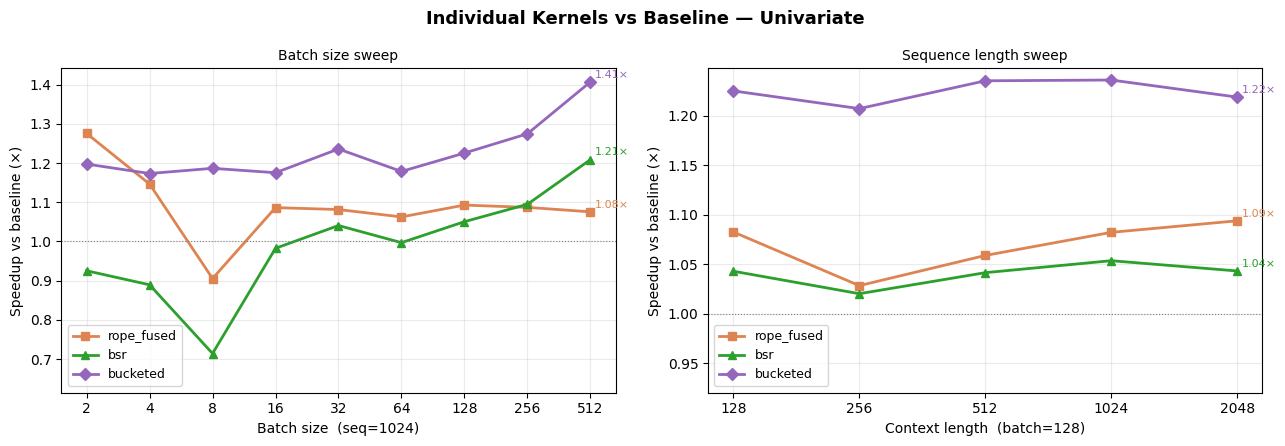

Saved → artifacts/comprehensive_benchmark/partA_univariate.png


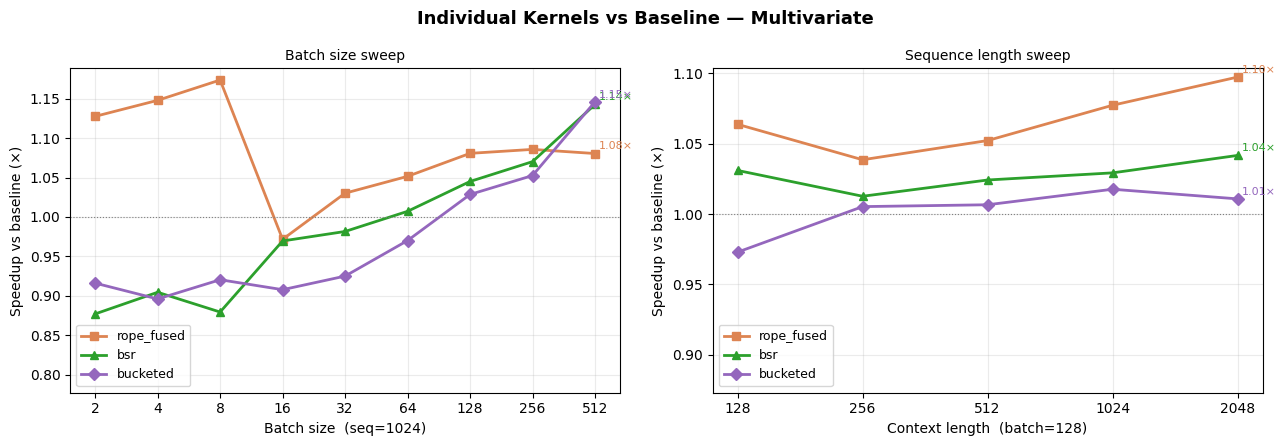

Saved → artifacts/comprehensive_benchmark/partA_multivariate.png


In [16]:
def _plot_speedup_pair(
    batch_x, batch_results,
    seq_x,   seq_results,
    model_names_plot,
    mode, title, save_path,
):
    """One figure per variate mode: left = batch-sweep speedup, right = seq-sweep speedup."""
    fig, (ax_b, ax_s) = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    base_batch = np.array(batch_results['baseline'])
    base_seq   = np.array(seq_results['baseline'])

    all_su_b = []
    all_su_s = []

    for name in model_names_plot:
        if name == 'baseline':
            continue
        su_b = base_batch / np.array(batch_results[name])
        su_s = base_seq   / np.array(seq_results[name])
        all_su_b.append(su_b)
        all_su_s.append(su_s)

        ax_b.plot(batch_x, su_b, marker=MARKERS[name], ls='-',
                  color=COLORS[name], lw=2.0, label=name)
        ax_b.annotate(f'{su_b[-1]:.2f}×', xy=(batch_x[-1], su_b[-1]),
                      xytext=(3, 3), textcoords='offset points',
                      fontsize=8, color=COLORS[name])

        ax_s.plot(seq_x, su_s, marker=MARKERS[name], ls='-',
                  color=COLORS[name], lw=2.0, label=name)
        ax_s.annotate(f'{su_s[-1]:.2f}×', xy=(seq_x[-1], su_s[-1]),
                      xytext=(3, 3), textcoords='offset points',
                      fontsize=8, color=COLORS[name])

    ylim_b = min(np.concatenate(all_su_b)) - 0.1 if all_su_b else 0.5
    ylim_s = min(np.concatenate(all_su_s)) - 0.1 if all_su_s else 0.5

    for ax, x_vals, x_label, ylim in (
        (ax_b, batch_x, f'Batch size  (seq={SWEEP_SEQ})',          ylim_b),
        (ax_s, seq_x,   f'Context length  (batch={FIXED_BATCH})',   ylim_s),
    ):
        ax.axhline(1.0, color='grey', lw=0.8, ls=':')
        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel('Speedup vs baseline (×)', fontsize=10)
        ax.set_xscale('log', base=2)
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.xaxis.set_minor_formatter(mticker.NullFormatter())
        ax.set_xticks(x_vals)
        ax.set_ylim(bottom=ylim)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=9)

    ax_b.set_title('Batch size sweep', fontsize=10)
    ax_s.set_title('Sequence length sweep', fontsize=10)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


# Part A — one figure per variate mode
for mode in VARIATE_MODES:
    _plot_speedup_pair(
        batch_x=BATCH_SIZES, batch_results=part_a_batch[mode],
        seq_x=SEQ_LENS,      seq_results=part_a_seq[mode],
        model_names_plot=PART_A_NAMES,
        mode=mode,
        title=f'Individual Kernels vs Baseline — {mode.capitalize()}',
        save_path=OUTPUT_DIR / f'partA_{mode}.png',
    )


## 8. Visualization — Part B: Combined Kernels vs Baseline

One figure per variate mode (univariate / multivariate).  
Each figure shows two speedup panels side by side: **batch size sweep** (left) and **sequence length sweep** (right).  
Compares `rope_bsr` (RoPE + BSR) and `rope_bucketed` (RoPE + Bucketed) against baseline.


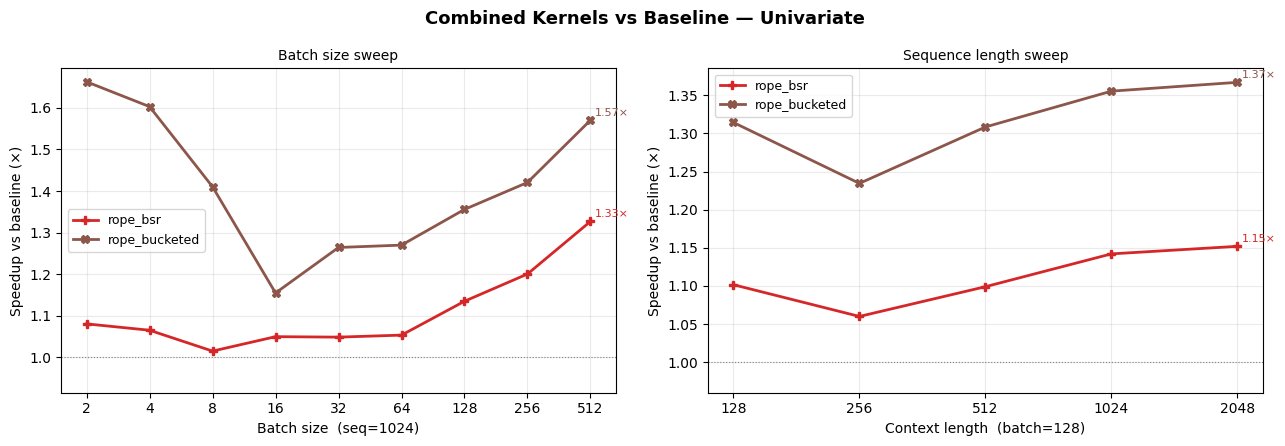

Saved → artifacts/comprehensive_benchmark/partB_univariate.png


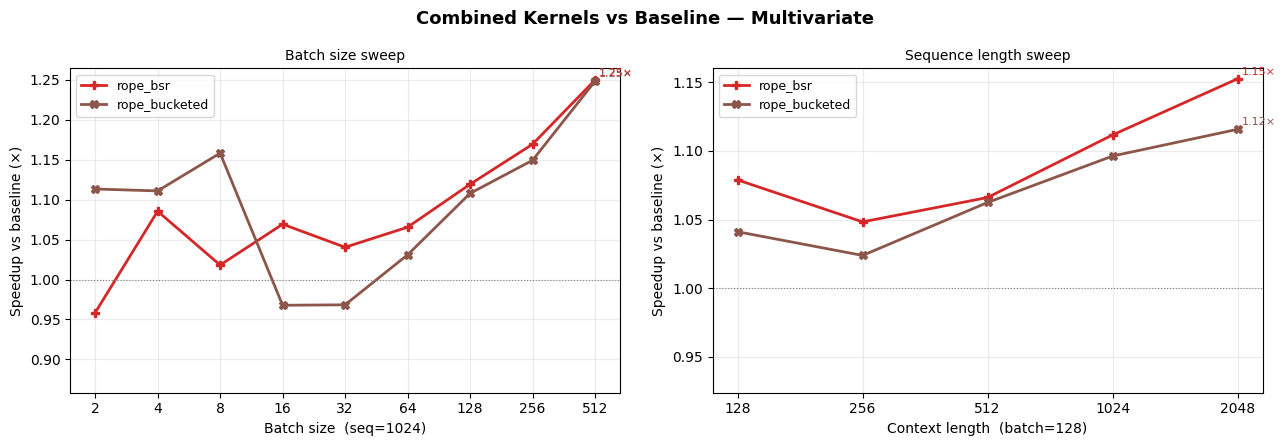

Saved → artifacts/comprehensive_benchmark/partB_multivariate.png


In [17]:
# Part B — one figure per variate mode
for mode in VARIATE_MODES:
    _plot_speedup_pair(
        batch_x=BATCH_SIZES, batch_results=part_b_batch[mode],
        seq_x=SEQ_LENS,      seq_results=part_b_seq[mode],
        model_names_plot=PART_B_NAMES,
        mode=mode,
        title=f'Combined Kernels vs Baseline — {mode.capitalize()}',
        save_path=OUTPUT_DIR / f'partB_{mode}.png',
    )


## 9. Memory Analysis

Measures **peak transient** GPU memory allocated above the static model weight baseline during a single forward pass.

Models compared: `baseline`, `rope_bsr` (static), `rope_bucketed` (retransformed per batch size).

Two sweeps per variate mode:
- **Sequence length** ∈ [128, 256, 512, 1024, 2048] at fixed batch = 4
- **Batch size** ∈ [1, 2, 4, 8, 16, 32, 64, 128, 256] at fixed seq = 1024

In [23]:
MEM_PART_B_NAMES = ['baseline', 'rope_bsr', 'rope_bucketed']

SEQ_LENS_MEM    = [128, 256, 512, 1024, 2048]
FIXED_BATCH_MEM = 128
BATCH_SIZES_MEM = [2, 4, 8, 16, 32, 64, 128, 256, 512]
FIXED_SEQ_MEM   = 1024

mem_seq   = {mode: {n: [] for n in MEM_PART_B_NAMES} for mode in VARIATE_MODES}
mem_batch = {mode: {n: [] for n in MEM_PART_B_NAMES} for mode in VARIATE_MODES}

# ── Sequence length sweep ────────────────────────────────────────────────────
for mode in VARIATE_MODES:
    gids_mem = make_gids(mode, FIXED_BATCH_MEM, DEVICE)

    # rope_bucketed: one retransform per mode (partition is seq-agnostic)
    _, rope_bucketed_mem = retransform_bucketed_models(
        model, FIXED_BATCH_MEM, gids_mem.cpu(), DEVICE
    )

    mem_models = {
        'baseline':      model,
        'rope_bsr':      STATIC_MODELS['rope_bsr'],
        'rope_bucketed': rope_bucketed_mem,
    }

    print(f'\nPeak transient memory — seq sweep  (batch={FIXED_BATCH_MEM}, {mode})')
    print(f"{'SeqLen':>7}  " + "  ".join(f"{n:>16}" for n in MEM_PART_B_NAMES))
    print('-' * 72)

    for seq in SEQ_LENS_MEM:
        ctx = torch.randn(FIXED_BATCH_MEM, seq, device=DEVICE)
        row = [f'{seq:>7}']
        for name, m in mem_models.items():
            def _fwd(m=m, ctx=ctx, gids=gids_mem):
                m(context=ctx, group_ids=gids, num_output_patches=OUT_PATCH)
            mem = measure_peak_memory(_fwd)
            mem_seq[mode][name].append(mem)
            row.append(f'{fmt_mb(mem):>16}')
        print('  '.join(row))

    del rope_bucketed_mem
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ── Batch size sweep ─────────────────────────────────────────────────────────
for mode in VARIATE_MODES:
    print(f'\nPeak transient memory — batch sweep  (seq={FIXED_SEQ_MEM}, {mode})')
    print(f"{'Batch':>6}  " + "  ".join(f"{n:>16}" for n in MEM_PART_B_NAMES))
    print('-' * 72)

    for bs in BATCH_SIZES_MEM:
        gids_mem = make_gids(mode, bs, DEVICE)

        # rope_bucketed must be retransformed per batch size
        _, rope_bucketed_mem = retransform_bucketed_models(
            model, bs, gids_mem.cpu(), DEVICE
        )

        mem_models = {
            'baseline':      model,
            'rope_bsr':      STATIC_MODELS['rope_bsr'],
            'rope_bucketed': rope_bucketed_mem,
        }

        ctx = torch.randn(bs, FIXED_SEQ_MEM, device=DEVICE)
        row = [f'{bs:>6}']
        for name, m in mem_models.items():
            def _fwd(m=m, ctx=ctx, gids=gids_mem):
                m(context=ctx, group_ids=gids, num_output_patches=OUT_PATCH)
            mem = measure_peak_memory(_fwd)
            mem_batch[mode][name].append(mem)
            row.append(f'{fmt_mb(mem):>16}')
        print('  '.join(row))

        del rope_bucketed_mem
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


Peak transient memory — seq sweep  (batch=128, univariate)
 SeqLen          baseline          rope_bsr     rope_bucketed
------------------------------------------------------------------------
    128          132.7 MB          105.1 MB           87.4 MB
    256          172.7 MB          138.4 MB          114.6 MB
    512          251.1 MB          205.2 MB          169.5 MB
   1024          410.4 MB          339.2 MB          279.5 MB
   2048          727.7 MB          607.3 MB          499.5 MB

Peak transient memory — seq sweep  (batch=128, multivariate)
 SeqLen          baseline          rope_bsr     rope_bucketed
------------------------------------------------------------------------
    128          132.0 MB          105.1 MB          105.1 MB
    256          172.0 MB          138.2 MB          138.2 MB
    512          250.6 MB          205.2 MB          205.2 MB
   1024          410.8 MB          340.1 MB          340.1 MB
   2048          727.0 MB          607.3 MB       

## 10. Memory Visualization

One figure per variate mode: **left** = memory vs sequence length, **right** = memory vs batch size.  
Top panel shows absolute transient memory (MB); bottom panel shows memory savings vs baseline (%).


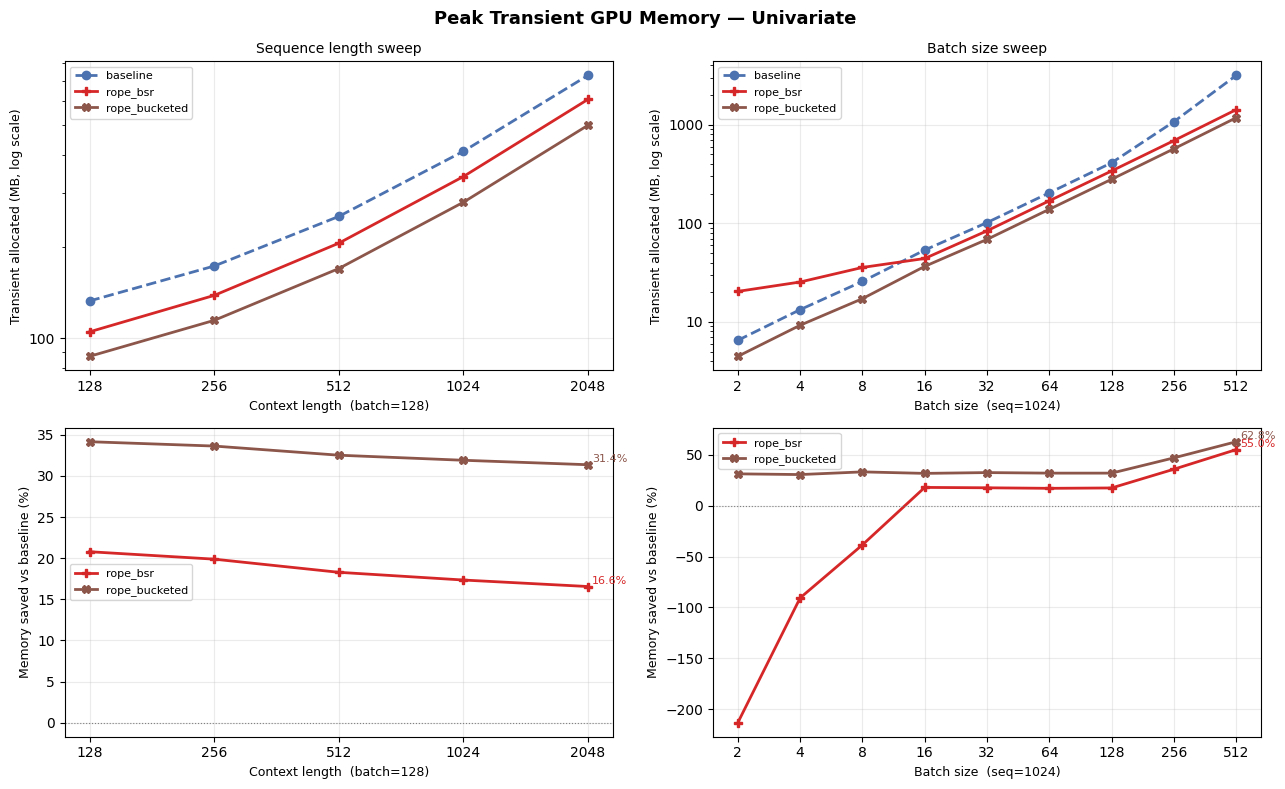

Saved → artifacts/comprehensive_benchmark/memory_univariate.png


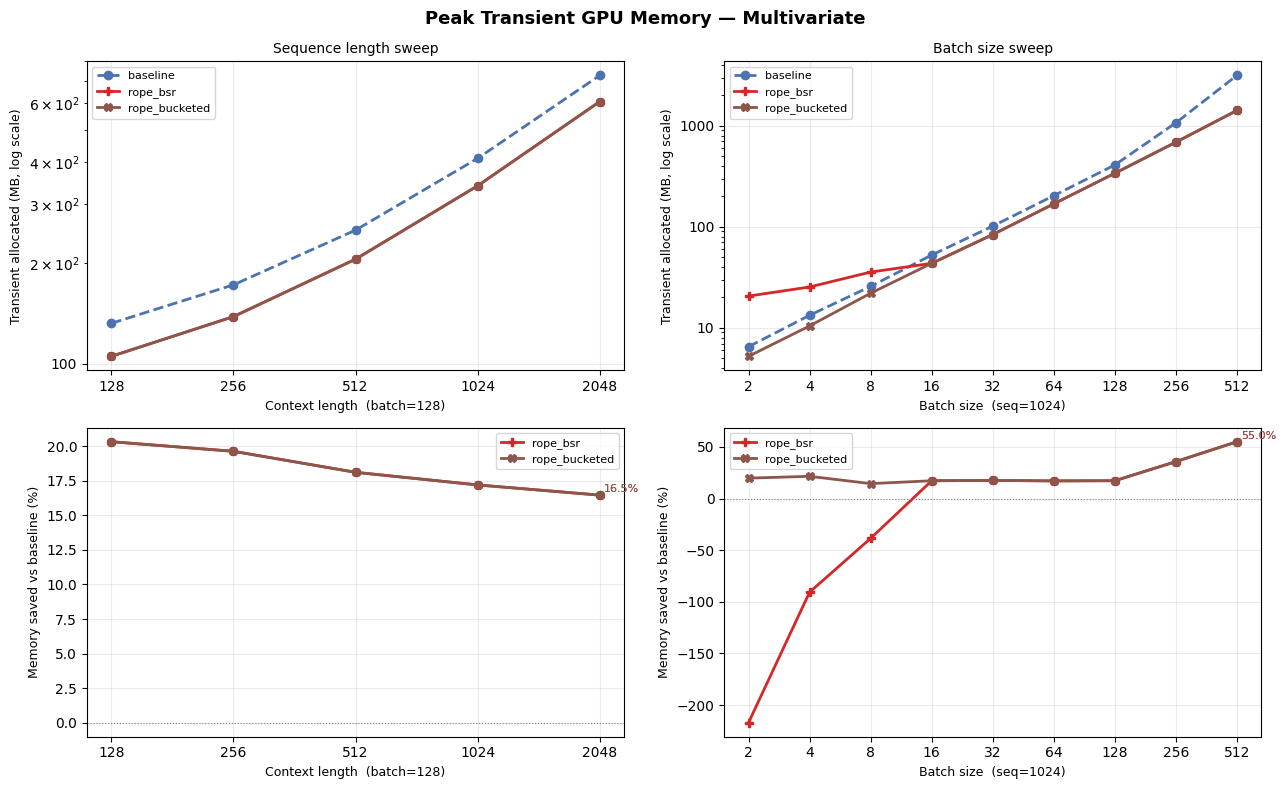

Saved → artifacts/comprehensive_benchmark/memory_multivariate.png


In [ ]:
MEM_COLORS = {k: COLORS[k] for k in MEM_PART_B_NAMES}
MEM_MARKERS = {k: MARKERS[k] for k in MEM_PART_B_NAMES}


def _plot_memory_pair(mode, mem_seq_d, mem_batch_d, save_path):
    """Two-column figure: seq-length sweep (left) and batch-size sweep (right).
    Each column has two rows: absolute MB (top) and % savings vs baseline (bottom).
    Seq sweep y-axis is linear; batch sweep y-axis is log scale.
    """
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle(f'Peak Transient GPU Memory — {mode.capitalize()}', fontsize=13, fontweight='bold')

    ax_seq_abs, ax_bat_abs = axes[0]
    ax_seq_sav, ax_bat_sav = axes[1]

    configs = [
        (ax_seq_abs, ax_seq_sav, SEQ_LENS_MEM,   mem_seq_d,   f'Context length  (batch={FIXED_BATCH_MEM})', False),
        (ax_bat_abs, ax_bat_sav, BATCH_SIZES_MEM, mem_batch_d, f'Batch size  (seq={FIXED_SEQ_MEM})',         True),
    ]

    for ax_abs, ax_sav, x_vals, mem_d, x_label, use_log in configs:
        base_mb = np.array(mem_d['baseline']) / 1024**2

        for name in MEM_PART_B_NAMES:
            mb = np.array(mem_d[name]) / 1024**2
            ls = '--' if name == 'baseline' else '-'
            ax_abs.plot(x_vals, mb, marker=MEM_MARKERS[name], ls=ls,
                        color=MEM_COLORS[name], lw=2.0, label=name)

        if use_log:
            ax_abs.set_yscale('log')
            ax_abs.yaxis.set_major_formatter(mticker.ScalarFormatter())
            ax_abs.set_ylabel('Transient allocated (MB, log scale)', fontsize=9)
        else:
            ax_abs.set_ylabel('Transient allocated (MB)', fontsize=9)
        ax_abs.set_xlabel(x_label, fontsize=9)

        for name in MEM_PART_B_NAMES:
            if name == 'baseline':
                continue
            mb    = np.array(mem_d[name]) / 1024**2
            saved = np.where(base_mb > 0, 100.0 * (base_mb - mb) / base_mb, 0.0)
            ax_sav.plot(x_vals, saved, marker=MEM_MARKERS[name], ls='-',
                        color=MEM_COLORS[name], lw=2.0, label=name)
            ax_sav.annotate(f'{saved[-1]:.1f}%', xy=(x_vals[-1], saved[-1]),
                            xytext=(3, 2), textcoords='offset points',
                            fontsize=8, color=MEM_COLORS[name])

        ax_sav.axhline(0, color='grey', lw=0.8, ls=':')
        ax_sav.set_ylabel('Memory saved vs baseline (%)', fontsize=9)
        ax_sav.set_xlabel(x_label, fontsize=9)

        for ax in (ax_abs, ax_sav):
            ax.set_xscale('log', base=2)
            ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
            ax.xaxis.set_minor_formatter(mticker.NullFormatter())
            ax.set_xticks(x_vals)
            ax.grid(True, alpha=0.25)
            ax.legend(fontsize=8)

    ax_seq_abs.set_title('Sequence length sweep', fontsize=10)
    ax_bat_abs.set_title('Batch size sweep', fontsize=10)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


for mode in VARIATE_MODES:
    _plot_memory_pair(
        mode=mode,
        mem_seq_d=mem_seq[mode],
        mem_batch_d=mem_batch[mode],
        save_path=OUTPUT_DIR / f'memory_{mode}.png',
    )


## 11. Summary Tables

In [12]:
import pandas as pd

for part_label, names, batch_res, seq_res in [
    ('A — Individual Kernels', PART_A_NAMES, part_a_batch, part_a_seq),
    ('B — Combined Kernels',   PART_B_NAMES, part_b_batch, part_b_seq),
]:
    print(f'\n{"═" * 70}')
    print(f'Part {part_label}')
    print(f'{"═" * 70}')

    non_baseline = [n for n in names if n != 'baseline']

    for mode in VARIATE_MODES:
        print(f'\n  Speedup vs baseline — batch sweep ({mode}, seq={SWEEP_SEQ})')
        rows = []
        for i, bs in enumerate(BATCH_SIZES):
            base_t = batch_res[mode]['baseline'][i]
            row = {'batch': bs}
            for n in non_baseline:
                row[f'{n}_speedup'] = round(base_t / batch_res[mode][n][i], 3)
            rows.append(row)
        print(pd.DataFrame(rows).set_index('batch').to_string())

        print(f'\n  Speedup vs baseline — seq sweep ({mode}, batch={FIXED_BATCH})')
        rows = []
        for i, seq in enumerate(SEQ_LENS):
            base_t = seq_res[mode]['baseline'][i]
            row = {'seq': seq}
            for n in non_baseline:
                row[f'{n}_speedup'] = round(base_t / seq_res[mode][n][i], 3)
            rows.append(row)
        print(pd.DataFrame(rows).set_index('seq').to_string())

# List saved plots
print(f'\nPlots saved to {OUTPUT_DIR}/')
for p in sorted(OUTPUT_DIR.glob('*.png')):
    print(f'  {p.name}')


══════════════════════════════════════════════════════════════════════
Part A — Individual Kernels
══════════════════════════════════════════════════════════════════════

  Speedup vs baseline — batch sweep (univariate, seq=1024)
       rope_fused_speedup  bsr_speedup  bucketed_speedup
batch                                                   
2                   1.276        0.925             1.198
4                   1.147        0.890             1.173
8                   0.906        0.714             1.187
16                  1.086        0.983             1.175
32                  1.081        1.041             1.236
64                  1.063        0.997             1.179
128                 1.093        1.051             1.226
256                 1.087        1.095             1.275
512                 1.076        1.209             1.407

  Speedup vs baseline — seq sweep (univariate, batch=128)
      rope_fused_speedup  bsr_speedup  bucketed_speedup
seq                        